# Template for Spectral and temporal modifications Lab


*From R. Badeau and G. Richard (with help from P. Vernhet), MAJ:2019*

**python version : 3.6**

Students: Karina Musina and Yossri HDIJI

In [164]:
import os, sys, wave, struct

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import IPython

from copy import deepcopy
from math import ceil
from scipy.io.wavfile import write

from scipy.signal.windows import hann

from IPython.display import Audio

## Functions

In [153]:
def load_sound(file):
    return wave.open(file, 'rb')
    
def plot_sound(data, times, name='default_name', save=False):
    plt.figure(figsize=(30, 4))
    plt.fill_between(times, data)
    plt.xlim(times[0], times[-1])
    plt.xlabel('time (s)')
    plt.ylabel('amplitude')
    if save:
        plt.savefig(name+'.png', dpi=100)
    plt.show()

def nextpow2(x):
    assert x>0
    p = ceil(np.log2(x))
    x_ = 2**p
    assert 2**(p-1) < x <= x_
    return p, x_

def period(x, Fs, Pmin=1/300, Pmax=1/80, seuil=0.7) :
    # [P,voiced] = period(x,Fs,Pmin,Pmax,seuil);
    # If voiced = 1, P is the period signal x expressed in number of samples
    # If voiced = 0, P is equal to 10ms.Fs

    x = x - np.mean(x)
    N = len(x)

    Nmin = np.ceil(Pmin*Fs).astype(int)
    Nmax = 1 + np.floor(Pmax*Fs).astype(int)
    Nmax = np.min([Nmax,N])

    _,Nfft = nextpow2(2*N-1)
    X = np.fft.fft(x, n=Nfft)
    S = X * np.conj(X) / N
    r = np.real(np.fft.ifft(S))

    rmax = np.max(r[Nmin:Nmax])
    I = np.argmax(r[Nmin:Nmax])
    P = I+Nmin
    corr = (rmax/r[0]) * (N/(N-P))
    voiced = corr > seuil
    if not(voiced):
        P = np.round(10e-3*Fs)

    return P,voiced

## Reading and playing .wav file

Choose the name of sound for the rest of the notebook. Sounds are assumed to be set in a folder named 'sons_mutltipitch' (same directory as notebook).

In [154]:
data_path = os.getcwd()
filename = 'new_aeiou.wav'
sound = os.path.join(data_path, filename) 

### **Using wave**

In [92]:
wavefile = load_sound(sound)
print(wavefile.getparams())

_wave_params(nchannels=1, sampwidth=2, framerate=11025, nframes=59964, comptype='NONE', compname='not compressed')


In [133]:
IPython.display.Audio('aeiou.wav')

In [94]:
Fs = int(wavefile.getframerate())
num_samples = int(wavefile.getnframes())
data = wavefile.readframes(num_samples)
data = struct.unpack('{n}h'.format(n=num_samples), data)
x = np.array(data)

In [95]:
timestep = 1/float(Fs)
times = np.arange(len(x))*timestep

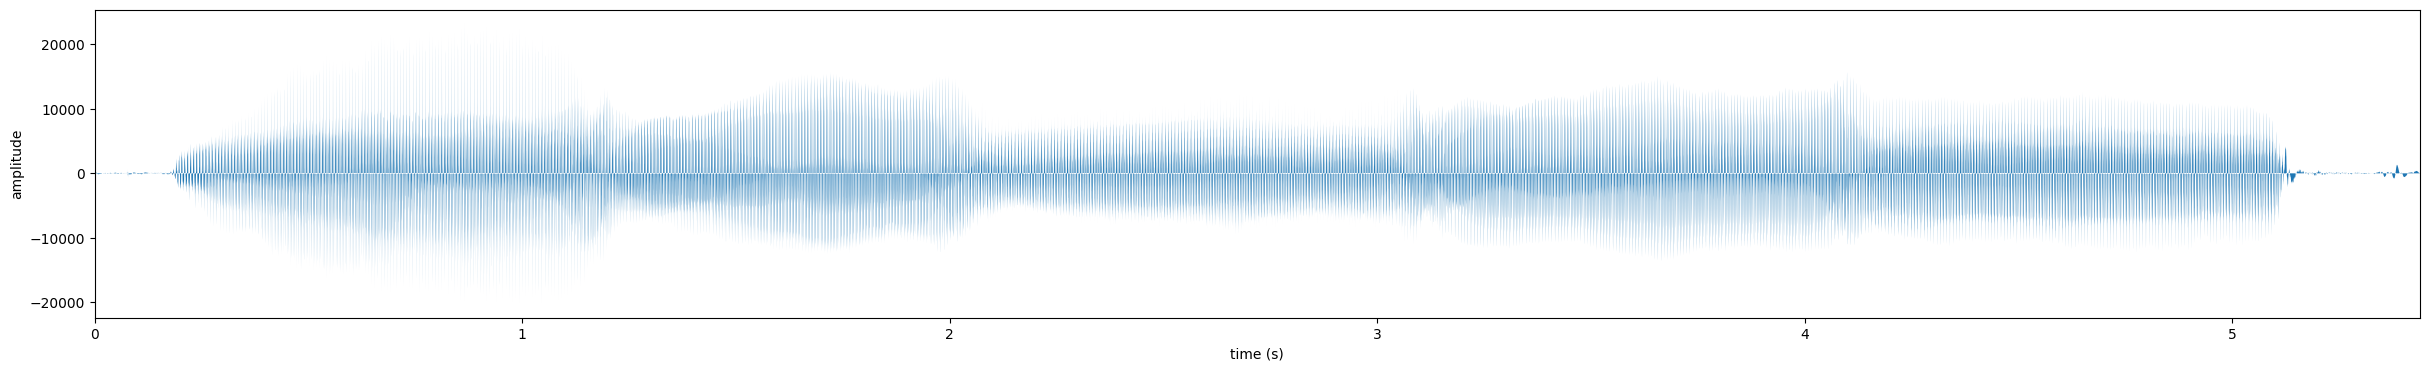

In [96]:
plot_sound(x, times)

In [97]:
write('new_aeiou.wav', Fs, np.array(x, dtype=np.int16)) # to write a new wave file

In [98]:
P,voiced = period(x, Fs)
P, voiced

(np.int64(83), np.True_)

# Part 1: Extraction of the analysis marks

In [150]:
def AnalysisPitchMarks(s, Fs):
    ta_list = []
    Pa_list = []
    
    ta = 0
    Pa = int(round(0.01 * Fs))  # 10 ms
    
    Pmax = int(1 + np.floor((1/80) * Fs)) 
    
    while ta < len(s):
        start = int(ta)
        end = int(start + 2.5 * Pa)
        end = min(end, len(s))
        
        if end - start < Pmax:
            break
        
        ta_list.append(ta)
        Pa_list.append(Pa)
        
        x = s[start:end]
        Pa, _ = period(x, Fs)
        Pa = int(round(Pa))
        ta = ta + Pa
    
    A = np.array([ta_list, Pa_list])
    
    return A

In [151]:
A = AnalysisPitchMarks(x, Fs)

# Part 2: Synthesis and modification of the temporal and spectral scales
## 2.1 Signal synthesis

In [104]:
def Synthesis(s, Fs, A, B):
    k_max = B.shape[1] 

    nk_end =  int(B[1, k_max - 1])
    Pa_end = int(A[1, nk_end])
    ts_end = int(B[0, k_max - 1])
    y = np.zeros(ts_end + Pa_end + 1)

    for k in range(k_max):
        
        nk = int(B[1, k])
        ta = int(A[0, nk])
        Pa = int(A[1, nk])

        width = 2 * Pa + 1

        start = ta - Pa
        end = ta + Pa + 1  

        # clip s
        s_start = max(0, start)
        s_end = min(len(s), end)

        x = s[s_start:s_end]

        # Hann
        xw = x * hann(len(x), sym=True)

        ts = int(B[0, k])

        # zone y 
        y_start = ts - Pa
        y_end = ts + Pa + 1

        # clip y + alignement xw
        yy_start = max(0, y_start)
        yy_end = min(len(y), y_end)

        # shift in xw
        xw_start = yy_start - y_start
        xw_end   = min(len(xw), xw_start + xw_start + (yy_end - yy_start))
        
        yy_end = yy_start + (xw_end - xw_start)

        if yy_end > yy_start and xw_end > xw_start:
            y[yy_start:yy_end] += xw[xw_start:xw_end]

    return y


### Synthesis test (reconstruction without modification)

In [155]:
test_B = np.zeros_like(A)
test_B[0,:] = A[0,:]
test_B[1,:] = range(0,A.shape[1]) 

In [158]:
print(test_B)

[[    0   110   220 ... 57627 57737 57847]
 [    0     1     2 ...   685   686   687]]


In [159]:
print(A)

[[    0   110   220 ... 57627 57737 57847]
 [  110   110   110 ...    83   110   110]]


In [160]:
y = Synthesis(x,Fs,A,test_B) # should be a copy of the initial signal with this B
y

array([ 0.        , -0.06891941, -0.27806778, ..., -0.05381957,
       -0.01875913,  0.        ], shape=(57958,))

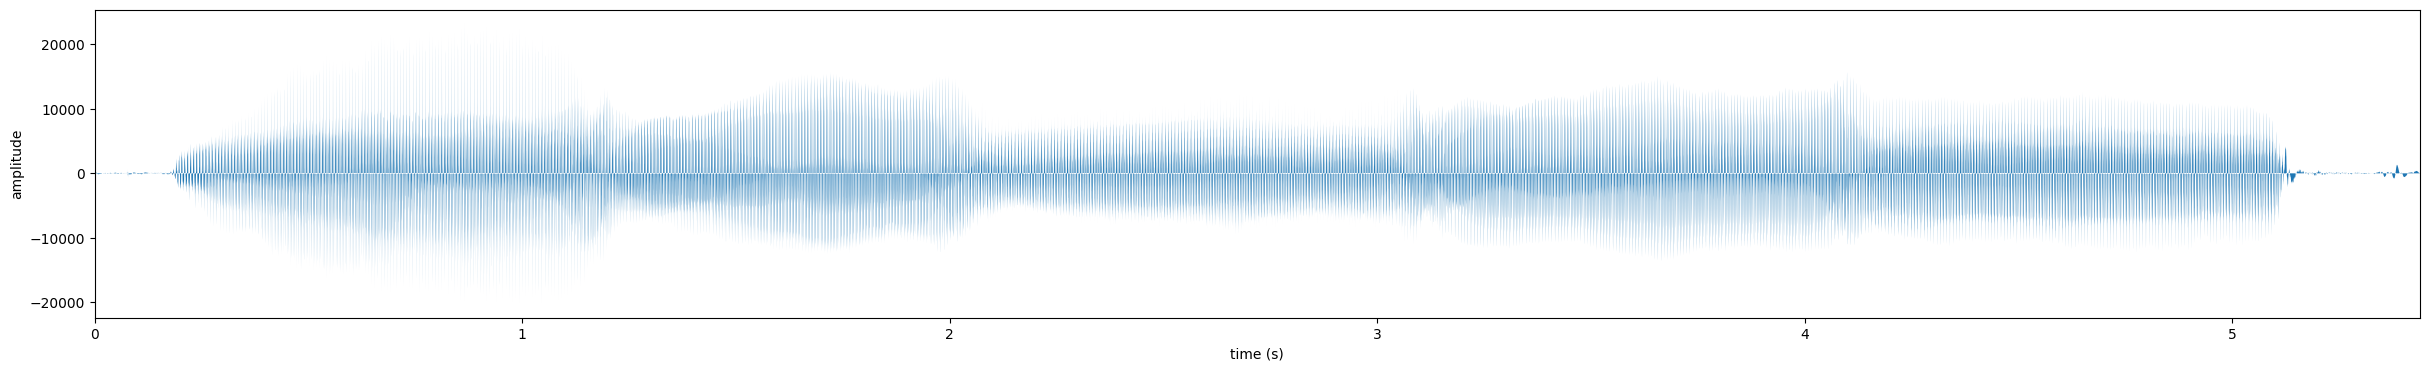

In [ ]:
# initial sound
timestep = 1/float(Fs)
times = np.arange(len(x))*timestep
plot_sound(x, times)

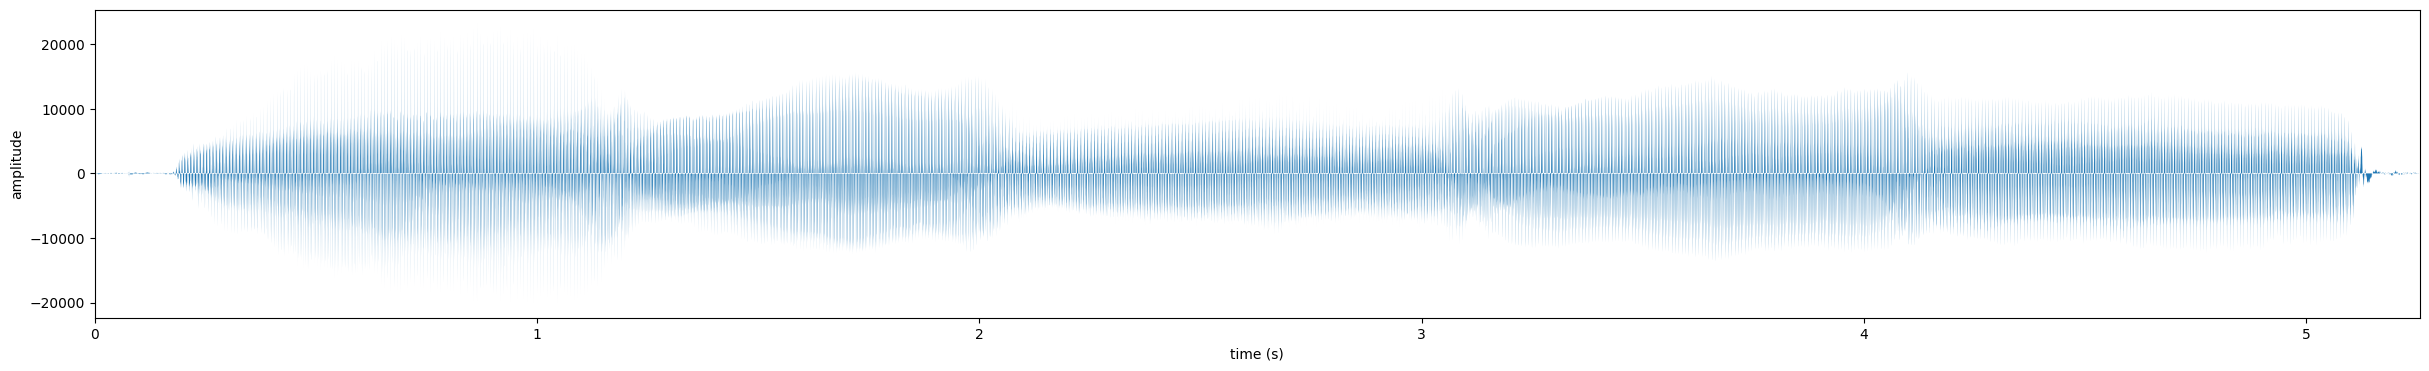

In [165]:
# reconstruction without modification
timestep = 1/float(Fs)
times = np.arange(len(y))*timestep
plot_sound(y, times)

In [166]:
Audio(y, rate=Fs)


## 2.2 Modification of the temporal scale

In [170]:
def ChangeTimeScale(alpha,A,Fs):

    ts_list= [1]
    nk_list = [0,1]
    ts = 1
    nk = 1
    N = A.shape[1]
        
    while int(np.floor(nk))<=N-1:
        
        ts += A[1,int(np.floor(nk))]
        nk +=  1/alpha
        
        ts_list.append(ts)
        nk_list.append(nk)
        
    
    
    B = np.array([ts_list, nk_list[:len(ts_list)]])
    return B
    

### Testing

#### $\alpha = 1/3$

In [ ]:
B = ChangeTimeScale(1/3,A,Fs)
y = Synthesis(x,Fs,A,B)


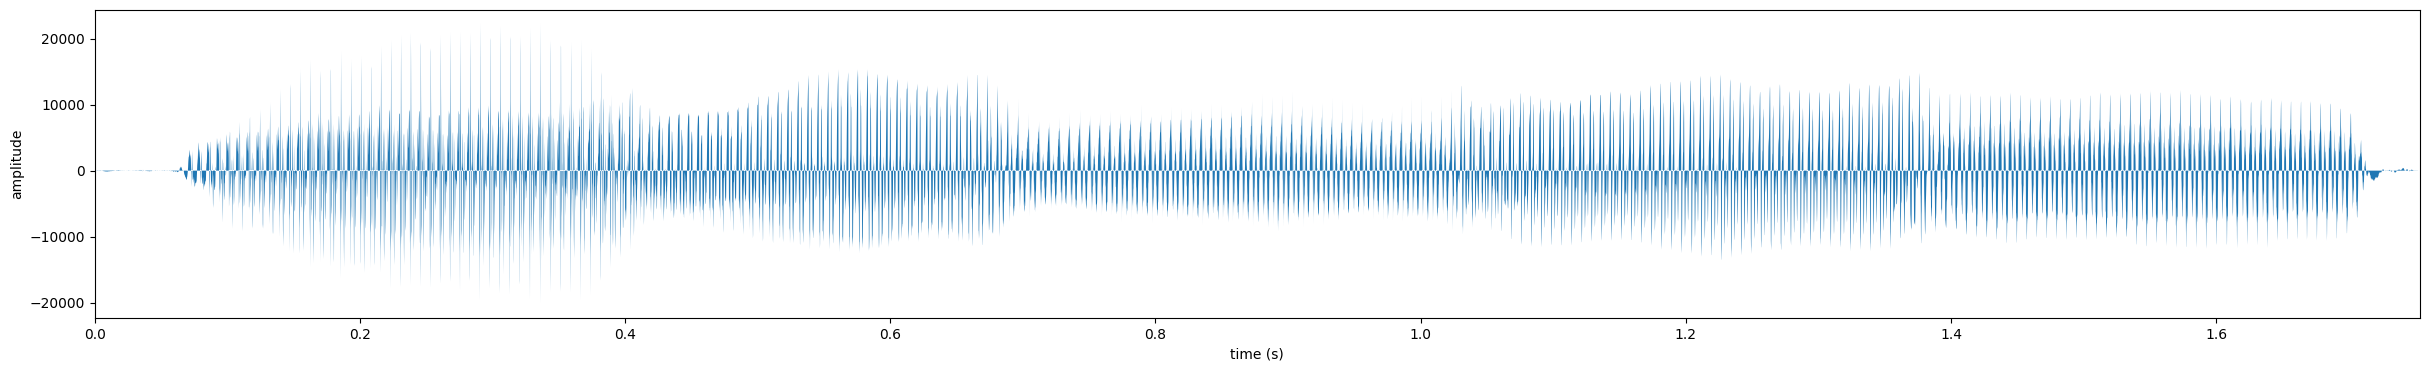

In [173]:
timestep = 1/float(Fs)
times = np.arange(len(y))*timestep
plot_sound(y, times)

In [174]:
Audio(y, rate=Fs)

#### $\alpha = 2.5$

In [176]:
B = ChangeTimeScale(2.5,A,Fs)
y = Synthesis(x,Fs,A,B)

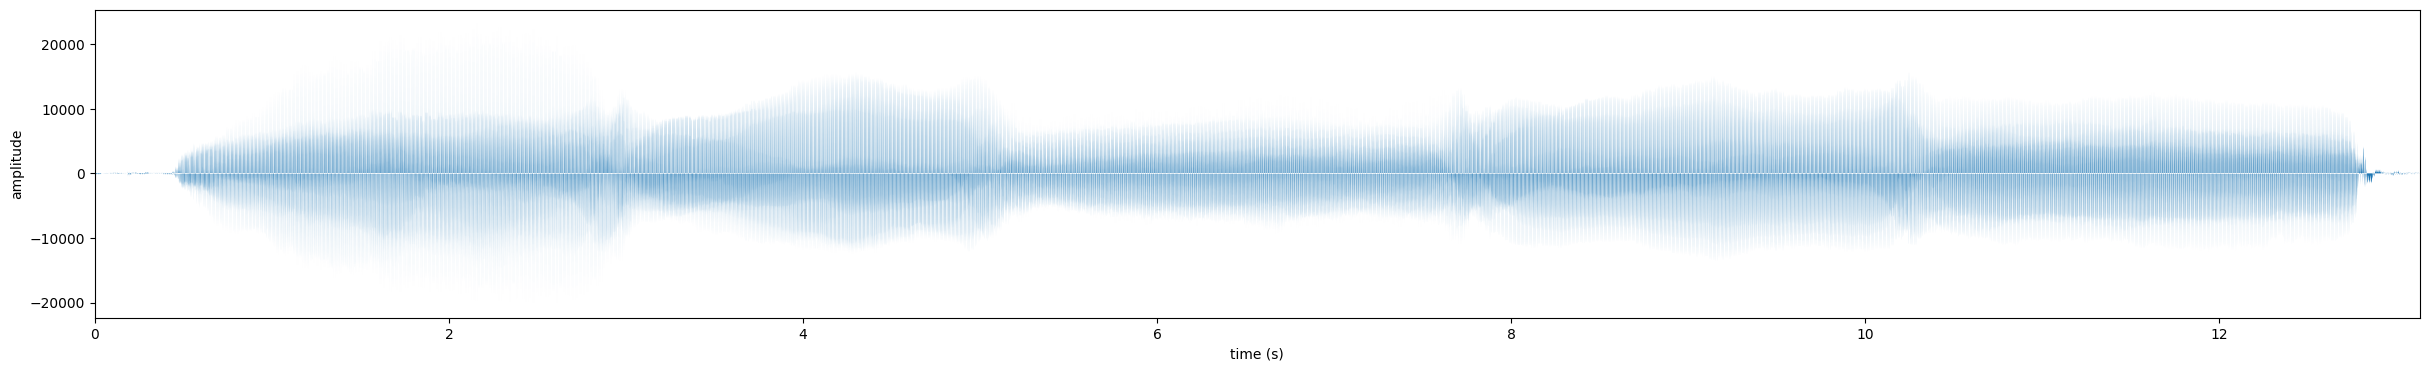

In [177]:
timestep = 1/float(Fs)
times = np.arange(len(y))*timestep
plot_sound(y, times)

In [178]:
Audio(y, rate=Fs)